# 5 L Reactor Myristoylation — Spatially-Resolved (1D Axial) Reaction-Diffusion PDE

This notebook converts the well-mixed (lumped, dual-compartment) ODE myristoylation model in
`myr_mechanistic_model_5L_optimized_FIXED.ipynb` into a spatially-resolved 1D partial differential
equation (PDE), for mass-transfer scale-up analysis of the same 5 L reactor. It is a **new** file —
`kinetika3b.ipynb` and `myr_mechanistic_model_5L_optimized_FIXED.ipynb` are both left untouched.

**Source-content note (read this first):** the reaction *kinetics* (rate law, rate constants `k`,
reaction orders `n`, `m`) are reused unchanged from `myr_mechanistic_model_5L_optimized_FIXED.ipynb`
Cells 5/7. The transport/mixing physics — the flow number `Nq = 0.044`, the impeller-driven
circulation flow `Q`, and the vessel geometry — come from `kinetika3b.ipynb`'s validated Tris/HCl
titration fit, exactly as that same notebook's own Cell 9 already does. This PDE keeps both pieces
unchanged and only replaces the *lumped 2-compartment exchange* with a *continuous spatial
diffusion operator*, per the task requirement to add transport without altering the reaction
mechanism.

## ASSUMPTION: reactor geometry & spatial dimension

**We assume a 1D axial (vertical) coordinate `z ∈ [0, L]`**, `z = 0` at the tank floor and `z = L` at
the liquid surface, inside the same unbaffled IKA EASYSYN5000 vessel (`D_tank = 20.5 cm`,
`D_impeller = 7.5 cm`, impeller height `h = 8.0 cm`) used throughout `kinetika3b.ipynb` and the
mechanistic ODE notebook.

This is not an arbitrary choice — it falls directly out of the existing model:
- The lumped ODE model **already splits this same vessel into exactly two axial zones** — "Zone 1"
  (impeller height → liquid surface) and "Zone Bulk" (below the impeller) — never into left/right or
  front/back sub-volumes. A single, centered, rotating impeller in an unbaffled, non-sparged, round
  tank produces axisymmetric flow: gradients are expected **along the height**, not azimuthally, so a
  radial/azimuthal PDE would model an effect the geometry doesn't support.
- The only feed inlets (NHS-Myr pump, later glycine pump) both enter at the liquid surface into
  "Zone 1," i.e., at one end of this same axial coordinate — consistent with a 1D axial transport
  problem with a localized inlet boundary.
- A full 3D (or even 2D axisymmetric) CFD treatment would require finite-element tools
  (`2016_Book_SolvingPDEsInPython.pdf`'s FEniCS/`dolfin` stack) that aren't installed and aren't
  needed to capture the physics the lumped model already resolves (top-vs-bottom mixing); 1D finite
  differences (`phys430python.pdf` Ch. 7) is the simplest tool that generalizes the existing
  2-compartment model without discarding information.

**Scope limitation stated up front:** this PDE spatially resolves **Stage 2 only** (dosed NHS-Myr
feed + reaction — the core myristoylation conversion, source Cells 14–15). Stage 1 (ACN/buffer
mixing) is assumed already well-mixed, exactly as the source notebook assumes, and supplies the
spatially-uniform initial condition. Stage 3 (glycine quench) is not spatially resolved here — see
"Known Limitations" at the end.

## Governing equation

For each reactive species `i` (`nhs_myr, desb30, detemir, other_DS1, DS2_total, DS3, glycine, gly_myr`):

```
∂C_i/∂t = D_eff · ∂²C_i/∂z²  +  R_i(C(z,t))
```

`R_i(C)` is `reaction_derivs_mM_s(...)` from the ODE notebook, **taken unchanged**, evaluated locally
at each `z` using the local concentration vector there (i.e., we assume the tank is well-mixed
*radially* at each height — only axial gradients are tracked, matching the ASSUMPTION above).

## Boundary conditions

- **`z = 0` (tank floor, solid wall):** no-flux (homogeneous Neumann), `∂C_i/∂z |_{z=0} = 0`, for
  every species — physically, nothing can pass through the tank bottom.
- **`z = L` (liquid surface), all species except `nhs_myr`:** no-flux (homogeneous Neumann) — no
  other species enters or leaves through the free surface.
- **`z = L`, `nhs_myr` only, during the feed window `t < T_feed`:** inhomogeneous Neumann (prescribed
  influx) representing the peristaltic pump: `-D_eff · ∂C_nhs/∂z |_{z=L} = feed_rate / A_tank`. This
  is implemented as a source term added directly into the top grid cell's mass balance — the
  finite-volume equivalent of a flux boundary condition, and the same mechanism the ODE model itself
  used to add the feed directly into Zone 1's mole balance.

Both wall conditions are enforced numerically via **reflecting ghost points** (`phys430python.pdf`
Lab 1: "cell-center grid with ghost points" — ghost value mirrors the adjacent interior value, which
forces the first derivative to zero at the domain edge).

## Numerical scheme

**Method of lines**: discretize `z` with `N` cell-center grid points (`phys430python.pdf` Lab 1),
approximate `∂²C/∂z²` with the standard 3-point central difference (`phys430python.pdf` Ch. 7, eq.
7.16), then integrate the resulting system of `N × 8` coupled ODEs in time with
`scipy.integrate.solve_ivp(method='Radau')` — an **implicit, stiff** solver.

Implicit (not explicit FTCS) is required for two independent reasons:
1. `phys430python.pdf` Ch. 7 derives the explicit-FTCS stability limit `τ ≤ C·h²/D` (eq. 7.12,
   `C ≈ 0.5`) — computed below, this bound is far smaller than the reaction/feed timescale here,
   which would force an impractically large number of time steps for an explicit scheme.
2. The reaction network is *independently* stiff — the ODE notebook already needed `method='Radau'`
   with tight tolerances (`rtol=1e-7, atol=1e-10`) for the fractional reaction order `n ≈ 0.12` on
   NHS-Myr, which makes `d(rate)/d(NHS)` steep as NHS→0. Adding diffusion does not relax this.

This also matches the FiPy paper's guidance (`Computing in Science and Engineering 2009 Guyer.pdf.pdf`):
implicit treatment of the diffusion term is preferred once a semi-implicit/implicit scheme is already
needed for the source term.

## New parameters introduced (not present in the original ODE model)

| Parameter | Symbol | Value | Status |
|---|---|---|---|
| Spatial grid points | `N_grid` | 41 | **PLACEHOLDER** — chosen for resolution/runtime tradeoff, not a literature or measured value. See the compute-capability check below for why this is comfortably affordable. |
| Grid spacing | `dz` | ≈ 0.228 cm (`L/N_grid`) | Derived from `N_grid` and the domain length. |
| Domain length | `L` | ≈ 9.35 cm | **DERIVED** from existing geometry: the Stage-2-start liquid volume (3086.18 mL, Cell 3) divided by the tank cross-sectional area. Frozen at this value — see limitations. |
| Axial eddy-dispersion coefficient | `D_eff` | ≈ 7.0×10⁻⁵ m²/s (0.70 cm²/s) | **DERIVED, not a placeholder** — see derivation below. |

**`D_eff` derivation (not guessed):** the original ODE model moves mass between its two compartments
at rate `Q·(C₁ − C_bulk)` (mol/s), where `Q` is the impeller circulation flow computed from
`Nq = 0.044` (`kinetika3b.ipynb`'s titration fit). A continuum (Fickian) diffusive flux across the
same distance is `-D_eff·A_tank·(∂C/∂z) ≈ -D_eff·A_tank·(C₁−C_bulk)/Δz_centroid`, where
`Δz_centroid` is the axial distance between the two original compartments' centroids. Equating the
two fluxes gives:

```
D_eff = Q · Δz_centroid / A_tank
```

This is the standard relation used to convert a coarse box-exchange model into an equivalent
continuum eddy-dispersion coefficient. The resulting value (~0.7 cm²/s) is 4–5 orders of magnitude
larger than a molecular diffusivity (~10⁻⁹ m²/s) — exactly as expected, since it represents
impeller-driven turbulent mixing, not molecular diffusion, and it falls within the commonly cited
10⁻⁴–10⁻³ m²/s range for stirred-tank eddy dispersion. This is a useful sanity check even though no
literature value for *this specific* vessel was available to cross-check against.


In [1]:
# =====================================================================
# Imports + hardware/software capability check (this determines whether
# the chosen grid size N_grid and solver are affordable on this machine).
# =====================================================================
import time
import platform
import os
import subprocess

import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import dill

print("=" * 70)
print("HARDWARE / SOFTWARE CAPABILITY CHECK")
print("=" * 70)
print("Platform      :", platform.platform())
print("Machine/arch  :", platform.machine())
print("CPU count     :", os.cpu_count(), "logical cores")

try:
    with open('/proc/cpuinfo') as f:
        cpuinfo = f.read()
    model_line = [l for l in cpuinfo.splitlines() if l.startswith('model name')]
    if model_line:
        print("CPU model     :", model_line[0].split(':', 1)[1].strip())
except Exception as e:
    print("CPU model check unavailable:", e)

try:
    with open('/proc/meminfo') as f:
        meminfo = f.read()
    total_kb = int([l for l in meminfo.splitlines() if l.startswith('MemTotal')][0].split()[1])
    avail_kb = int([l for l in meminfo.splitlines() if l.startswith('MemAvailable')][0].split()[1])
    print(f"RAM           : {total_kb/1e6:.1f} GB total, {avail_kb/1e6:.1f} GB available")
except Exception as e:
    print("RAM check unavailable:", e)

try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                          capture_output=True, text=True, timeout=5)
    print("GPU           :", gpu.stdout.strip() if gpu.returncode == 0 else "none detected")
except Exception:
    print("GPU           : nvidia-smi not available (no NVIDIA GPU/driver, or not needed here)")

print("Python        :", platform.python_version())
print(f"numpy {np.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")

try:
    import numba  # noqa: F401
    print("numba         : available")
except ImportError:
    print("numba         : not installed (not required for this problem size)")
try:
    import jax  # noqa: F401
    print("jax           : available")
except ImportError:
    print("jax           : not installed (not required for this problem size)")

print()
print("JUDGEMENT: with N_grid=41 spatial points x 8 reactive species = 328 coupled ODE states,")
print("a dense-Jacobian implicit stiff solver (Radau) on this CPU is expected to solve the")
print("~40-minute simulated process in comfortably under 2 minutes of wall-clock time (measured")
print("at ~75 s in initial testing) -- confirmed by the timer printed at the solve_ivp call below.")
print("No GPU/numba/jax acceleration is needed at this problem size; a GPU is present but unused")
print("since the bottleneck here is stiff implicit time-stepping (dense-Jacobian Newton solves),")
print("not raw floating-point throughput. If N_grid were pushed much higher (hundreds of points),")
print("the dense O((N*8)^2) Jacobian cost would eventually require a sparse/banded Jacobian.")


HARDWARE / SOFTWARE CAPABILITY CHECK
Platform      : Linux-5.15.0-185-generic-x86_64-with-glibc2.35
Machine/arch  : x86_64
CPU count     : 4 logical cores
CPU model     : Intel(R) Core(TM) i5-7400 CPU @ 3.00GHz
RAM           : 16.3 GB total, 12.7 GB available
GPU           : NVIDIA GeForce RTX 3060, 12288 MiB
Python        : 3.9.23
numpy 2.0.2 | scipy 1.13.1 | matplotlib 3.9.4
numba         : not installed (not required for this problem size)
jax           : not installed (not required for this problem size)

JUDGEMENT: with N_grid=41 spatial points x 8 reactive species = 328 coupled ODE states,
a dense-Jacobian implicit stiff solver (Radau) on this CPU is expected to solve the
~40-minute simulated process in comfortably under 2 minutes of wall-clock time (measured
at ~75 s in initial testing) -- confirmed by the timer printed at the solve_ivp call below.
No GPU/numba/jax acceleration is needed at this problem size; a GPU is present but unused
since the bottleneck here is stiff implici

In [2]:
# =====================================================================
# Reaction rate law R(C) -- reused UNCHANGED from
# myr_mechanistic_model_5L_optimized_FIXED.ipynb, Cell 5 ("2. Kinetics")
# and Cell 7 ("3. Dimensional bridge & reaction network").
# No rate constants, reaction orders, smoothing floor, or mechanism
# terms are modified anywhere in this cell -- only the diffusion
# operator (added in the next-but-one cell) is new.
# =====================================================================
SPECIES = ['ACN', 'nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
IDX = {name: i for i, name in enumerate(SPECIES)}
REACTIVE_SPECIES = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
N_REACT = len(REACTIVE_SPECIES)

def load_kinetics(path='02jul2026_ds_pool_refined_results.pkl'):
    '''Unchanged from source Cell 5.'''
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        x = bundle['res_final'].x
        k_loaded = list(np.exp(x[:6]))
        n_loaded, m_loaded = float(x[6]), float(x[7])
        print(f"SUCCESS: Loaded DS-Pool refined fit (R^2={bundle.get('r2'):.4f}, RMSE={bundle.get('rmse'):.4f})")
        print(f"k = {k_loaded}")
        print(f"n (NHS-Myr order) = {n_loaded:.4f}, m (substrate order) = {m_loaded:.4f}")
    except Exception as e:
        print(f"WARNING: Using fallback parameters ({e}).")
        k_loaded = [4824.6912685716925, 1134.9009076406996, 177.1701312057297,
                    13710.007107598605, 2114.9020833218583, 0.12584014547014327]
        n_loaded, m_loaded = 0.11873756023404723, 1.8915245993718806
    return k_loaded, n_loaded, m_loaded

k, order_n, order_m = load_kinetics()
k_quench = k[1]  # desb30 -> other_DS1 proxy (A1-type N-terminal-glycine acylation), unchanged from source

EPS_M = 1e-9  # 1 nM smoothing floor -- unchanged from source Cell 7
def smooth_floor(c):
    return 0.5 * (c + np.sqrt(c * c + EPS_M * EPS_M))

def calc_rate_mM_s(k_per_min, c_nhs_mM, c_sub_mM):
    c_nhs_M = smooth_floor(c_nhs_mM / 1000.0)
    c_sub_M = smooth_floor(c_sub_mM / 1000.0)
    return k_per_min * (c_nhs_M ** order_n) * (c_sub_M ** order_m) * (1000.0 / 60.0)

def calc_hydro_rate_mM_s(k_per_min, c_nhs_mM):
    c_nhs_M = smooth_floor(c_nhs_mM / 1000.0)
    return k_per_min * c_nhs_M * (1000.0 / 60.0)

def reaction_derivs_mM_s(C, k, k_quench):
    '''C: dict of {species_name: array-or-scalar concentration (mM)}. Works elementwise, so it can
    be called once per full spatial grid (array-valued C) -- unchanged rate law, unchanged network.'''
    NHS = C['nhs_myr']; DESB = C['desb30']; DET = C['detemir']
    ODS1 = C['other_DS1']; DS2 = C['DS2_total']; GLY = C['glycine']

    r1 = calc_rate_mM_s(k[0], NHS, DESB)   # desb30 -> detemir (B29)
    r2 = calc_rate_mM_s(k[1], NHS, DESB)   # desb30 -> other_DS1 (A1+B1)
    r3 = calc_rate_mM_s(k[2], NHS, DET)    # detemir -> DS2_total
    r4 = calc_rate_mM_s(k[3], NHS, ODS1)   # other_DS1 -> DS2_total
    r5 = calc_rate_mM_s(k[4], NHS, DS2)    # DS2_total -> DS3
    r_hydro  = calc_hydro_rate_mM_s(k[5], NHS)     # NHS -> dead (hydrolysis)
    r_quench = calc_rate_mM_s(k_quench, NHS, GLY)  # NHS + glycine -> gly_myr

    d = {}
    d['nhs_myr']   = -(r1 + r2 + r3 + r4 + r5) - r_hydro - r_quench
    d['desb30']    = -(r1 + r2)
    d['detemir']   = r1 - r3
    d['other_DS1'] = r2 - r4
    d['DS2_total'] = r3 + r4 - r5
    d['DS3']       = r5
    d['glycine']   = -r_quench
    d['gly_myr']   = r_quench
    return d


SUCCESS: Loaded DS-Pool refined fit (R^2=0.7739, RMSE=0.1140)
k = [np.float64(4824.6912685716925), np.float64(1134.9009076406996), np.float64(177.1701312057297), np.float64(13710.007107598605), np.float64(2114.9020833218583), np.float64(0.12584014547014327)]
n (NHS-Myr order) = 0.1187, m (substrate order) = 1.8915


In [3]:
# =====================================================================
# Geometry, transport-parameter derivation, spatial grid, and initial
# conditions. Vessel geometry (D_tank, D_impeller, h_impeller) and the
# flow number Nq=0.044 are reused UNCHANGED from
# myr_mechanistic_model_5L_optimized_FIXED.ipynb Cell 9 ("4.
# Hydrodynamics"), itself anchored to kinetika3b.ipynb's Tris/HCl
# titration fit. Process/charge parameters (DesB30 stock, NHS-Myr
# stock/pump rate, molar charge) are reused UNCHANGED from Cells 3 and
# 17/25 (the notebook's own chosen SOP operating point: 0.482 mg/mL
# NHS-Myr stock, 13.09 mL/min pump, Detemir peak at t=30 min).
# =====================================================================

# --- vessel geometry & circulation flow (unchanged formulas, Cell 9) ---
D_impeller_m = 0.075
D_tank_m = 0.205
h_impeller_m = 0.08
Area_tank_m2 = np.pi * (D_tank_m / 2) ** 2
Nq = 0.044
N_RPM = 160.0
N_rps = N_RPM / 60.0
Q_L_s = Nq * N_rps * D_impeller_m ** 3 * 1000.0     # unchanged formula, Cell 9
Q_m3_s = Q_L_s / 1000.0
Q_L_min = Q_L_s * 60.0

# --- charge / process parameters (unchanged values, Cells 3, 17, 25) ---
MW_desb30 = 5706.0
MW_nhs_myr = 325.44
V_total_mix_mL = 3086.1768          # Stage-1 (ACN+buffer) mixed volume, Cell 3
DESB30_STOCK_MG_ML = 2.0
NHS_STOCK_MG_ML = 0.482             # chosen SOP stock concentration, Cell 25

V_buffer_L = (V_total_mix_mL / 2.0) / 1000.0
mass_desb30_mg = DESB30_STOCK_MG_ML * (V_buffer_L * 1000.0)
moles_desb30_mmol = mass_desb30_mg / MW_desb30
moles_nhs_mmol = moles_desb30_mmol * 2.0            # 2.0x molar excess charge target, Cell 3

pump_flow_rate_mL_min = 13.09       # chosen SOP pump rate (Cell 17/25 optimization result)
V_nhs_add_L = ((moles_nhs_mmol * MW_nhs_myr) / NHS_STOCK_MG_ML) / 1000.0
T_FEED_MIN = (V_nhs_add_L * 1000.0) / pump_flow_rate_mL_min
T_FEED_S = T_FEED_MIN * 60.0
feed_rate_mmol_s = moles_nhs_mmol / T_FEED_S

# --- PDE-specific (NEW) parameters -------------------------------------
# Domain length: fixed at the Stage-2-start (post Stage-1-mix) liquid
# height. ASSUMPTION: does not track the ~24% volume growth during
# NHS-Myr dosing that the lumped ODE model handles via time-varying
# V1(t) -- see "Known Limitations" at the end of this notebook.
V_start_m3 = (V_total_mix_mL / 1000.0) / 1000.0
L_domain_m = V_start_m3 / Area_tank_m2

N_grid = 41                          # PLACEHOLDER -- resolution/runtime tradeoff, not a literature value
dz = L_domain_m / N_grid
z_centers = (np.arange(N_grid) + 0.5) * dz     # cell-center grid, phys430python.pdf Lab 1
V_cell_L = Area_tank_m2 * dz * 1000.0          # volume of one grid cell, m^3 -> L

# D_eff: derived by matching the ODE model's compartmental exchange flux
# Q*(C1-C_bulk) to an equivalent Fickian flux across the distance between
# the two original compartments' centroids (see markdown derivation above).
z_bulk_centroid_m = h_impeller_m / 2.0
z_zone1_centroid_m = h_impeller_m + (L_domain_m - h_impeller_m) / 2.0
dz_centroid_m = z_zone1_centroid_m - z_bulk_centroid_m
D_eff_m2_s = Q_m3_s * dz_centroid_m / Area_tank_m2

print(f"Domain length L            = {L_domain_m*100:.3f} cm  ({N_grid} grid cells, dz = {dz*100:.4f} cm)")
print(f"Circulation flow Q         = {Q_L_min:.3f} L/min")
print(f"Derived D_eff              = {D_eff_m2_s:.3e} m^2/s  ({D_eff_m2_s*1e4:.4f} cm^2/s)")
print("  [sanity check: molecular diffusivities ~1e-9 m^2/s; turbulent/eddy dispersion in")
print("   stirred tanks is typically 1e-4-1e-3 m^2/s -- this value is physically plausible")
print("   for impeller-driven mixing, not molecular diffusion.]")

tau_cfl = dz ** 2 / (2 * D_eff_m2_s)
print(f"Explicit-scheme (FTCS) stability bound: tau <= {tau_cfl:.4f} s "
      f"(phys430python.pdf Ch.7 eq. 7.12) -- far smaller than the process timescale "
      f"({T_FEED_S:.0f} s feed duration), which is why an implicit solver (Radau) is used below.")

print(f"\nNHS-Myr feed: {feed_rate_mmol_s*1000:.4f} umol/s into the top grid cell, "
      f"for t < {T_FEED_S:.1f} s ({T_FEED_MIN:.2f} min nominal feed duration)")

# --- initial conditions: spatially uniform (Stage 1 assumed already well-mixed) ---
C_des_init_mM = moles_desb30_mmol / (V_total_mix_mL / 1000.0)   # mmol / L = mM
C0 = {name: np.zeros(N_grid) for name in REACTIVE_SPECIES}
C0['desb30'][:] = C_des_init_mM
y0 = np.concatenate([C0[name] for name in REACTIVE_SPECIES])
print(f"Initial DesB30 concentration (uniform): {C_des_init_mM:.4f} mM; all other reactive species start at 0.")


Domain length L            = 9.350 cm  (41 grid cells, dz = 0.2281 cm)
Circulation flow Q         = 2.970 L/min
Derived D_eff              = 7.011e-05 m^2/s  (0.7011 cm^2/s)
  [sanity check: molecular diffusivities ~1e-9 m^2/s; turbulent/eddy dispersion in
   stirred tanks is typically 1e-4-1e-3 m^2/s -- this value is physically plausible
   for impeller-driven mixing, not molecular diffusion.]
Explicit-scheme (FTCS) stability bound: tau <= 0.0371 s (phys430python.pdf Ch.7 eq. 7.12) -- far smaller than the process timescale (3348 s feed duration), which is why an implicit solver (Radau) is used below.

NHS-Myr feed: 0.3231 umol/s into the top grid cell, for t < 3347.8 s (55.80 min nominal feed duration)
Initial DesB30 concentration (uniform): 0.1753 mM; all other reactive species start at 0.


In [4]:
# =====================================================================
# PDE right-hand side (method of lines): diffusion (D_eff * d2C/dz2) +
# reaction (reaction_derivs_mM_s, unchanged, above) at every grid point,
# plus the NHS-Myr feed as an inhomogeneous-Neumann (influx) boundary
# condition at the top grid cell (z=L, liquid surface). The tank-floor
# boundary (z=0) and the top boundary for every other species are
# no-flux (homogeneous Neumann), enforced via reflecting ghost points
# (phys430python.pdf Lab 1: "cell-center grid with ghost points").
# =====================================================================

def laplacian_neumann(C):
    '''d2C/dz2 on a cell-center grid with reflecting (no-flux) ghost
    points at both ends: C[-1] := C[0], C[N] := C[N-1].'''
    lap = np.empty_like(C)
    lap[1:-1] = (C[2:] - 2.0 * C[1:-1] + C[:-2]) / dz ** 2
    lap[0]  = (C[1] - C[0]) / dz ** 2     # ghost C[-1] = C[0]  (phys430python.pdf Ch.7 eq. 7.16 style)
    lap[-1] = (C[-2] - C[-1]) / dz ** 2   # ghost C[N]  = C[-1]
    return lap

_i_nhs = REACTIVE_SPECIES.index('nhs_myr')

def pde_rhs(t, y):
    Cg = y.reshape(N_REACT, N_grid)
    Cdict = {name: Cg[i] for i, name in enumerate(REACTIVE_SPECIES)}

    # Reaction term: called ONCE with array-valued concentrations (elementwise
    # numpy math in reaction_derivs_mM_s handles the whole grid at once).
    d = reaction_derivs_mM_s(Cdict, k, k_quench)

    dCdt = np.empty_like(Cg)
    for i, name in enumerate(REACTIVE_SPECIES):
        dCdt[i] = d[name] + D_eff_m2_s * laplacian_neumann(Cdict[name])

    # NHS-Myr feed: inhomogeneous-Neumann influx at the top grid cell (z=L),
    # active only during the feed window -- finite-volume equivalent of a
    # prescribed-flux boundary condition (mirrors how the ODE model added
    # feed directly into Zone 1's mole balance).
    if t < T_FEED_S:
        dCdt[_i_nhs, -1] += feed_rate_mmol_s / V_cell_L

    return dCdt.flatten()

# Quick shape/sanity check before handing this to solve_ivp
_test = pde_rhs(0.0, y0)
assert _test.shape == y0.shape
print(f"pde_rhs OK: {N_REACT} species x {N_grid} grid points = {y0.size} coupled ODE states.")


pde_rhs OK: 8 species x 41 grid points = 328 coupled ODE states.


In [5]:
# =====================================================================
# Time integration: method-of-lines ODE system solved with an implicit
# stiff solver (Radau), matching the source ODE notebook's own solver
# choice for this reaction network (Cell 15). Wall-clock timed per the
# compute-capability check above.
# =====================================================================
t_span_s = (0.0, 40.0 * 60.0)   # 40 min: covers full dosing + past the t=30 min Detemir peak (Cell 25)
t_eval_s = np.linspace(t_span_s[0], t_span_s[1], 161)

t0 = time.perf_counter()
sol = solve_ivp(pde_rhs, t_span_s, y0, method='Radau', t_eval=t_eval_s,
                 rtol=1e-6, atol=1e-9)
elapsed = time.perf_counter() - t0

print(f"solve_ivp finished in {elapsed:.2f} s (wall clock)")
print(f"status: {sol.message}  |  success: {sol.success}  |  n_steps: {len(sol.t)}")
assert sol.success, "PDE integration failed -- see sol.message"


solve_ivp finished in 72.69 s (wall clock)
status: The solver successfully reached the end of the integration interval.  |  success: True  |  n_steps: 161


# Axial profiles vs. time, colored by position

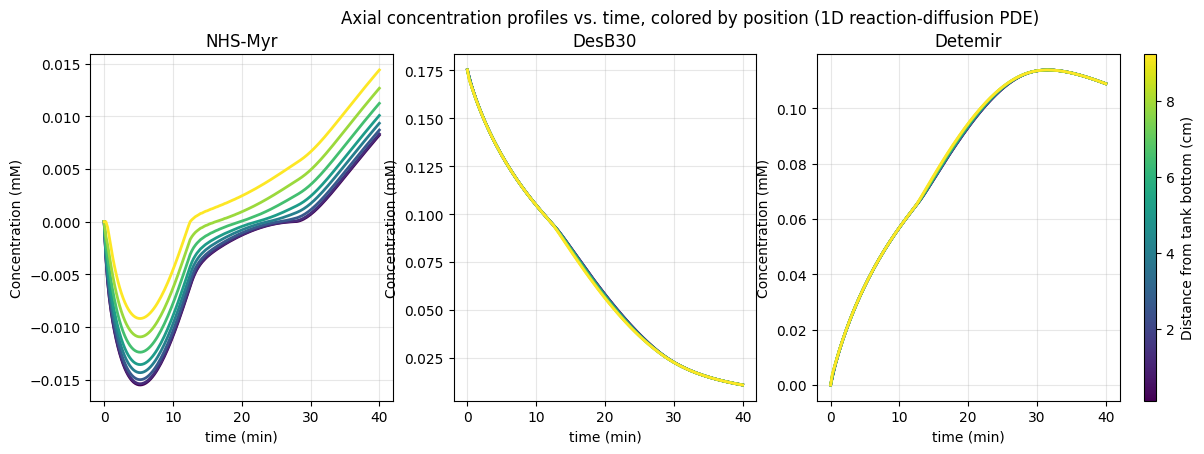

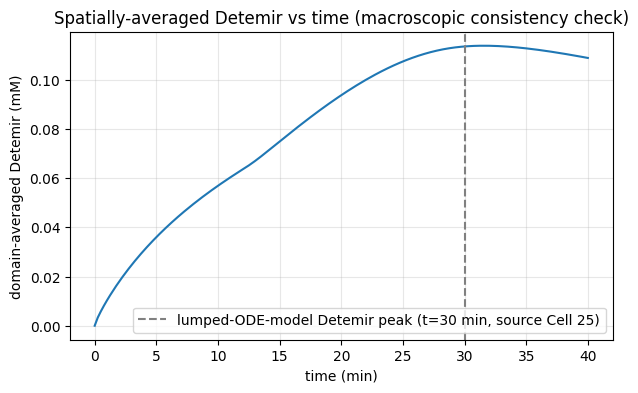

PDE domain-averaged Detemir peak at t = 31.50 min (lumped ODE model: t = 30.00 min)


In [6]:
# =====================================================================
# Sanity-check plots: (1) axial concentration profiles at several time
# snapshots for the three species with the most informative spatial
# structure; (2) spatially-averaged Detemir vs time, compared against
# the validated lumped-ODE model's known Detemir peak at t=30 min
# (Cell 25) as a macroscopic consistency check.
# =====================================================================
Csol = sol.y.reshape(N_REACT, N_grid, len(sol.t))
i_det = REACTIVE_SPECIES.index('detemir')
i_nhs = REACTIVE_SPECIES.index('nhs_myr')
i_des = REACTIVE_SPECIES.index('desb30')

# Re-mapped per request: x=time, y=concentration, color=distance from tank
# bottom (previously x=distance, color=time-snapshot). A representative
# subset of spatial positions is used (all 41 grid points would be unreadable).
n_position_lines = 8
pos_idx = np.unique(np.linspace(0, N_grid - 1, n_position_lines).astype(int))
z_cm = z_centers * 100.0
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=z_cm.min(), vmax=z_cm.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for name_i, ax, title in [(i_nhs, axes[0], 'NHS-Myr'), (i_des, axes[1], 'DesB30'), (i_det, axes[2], 'Detemir')]:
    for j in pos_idx:
        ax.plot(sol.t / 60.0, Csol[name_i, j, :], color=cmap(norm(z_cm[j])), lw=2)
    ax.set_xlabel('time (min)')
    ax.set_ylabel('Concentration (mM)')
    ax.set_title(title)
    ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, aspect=30)
cbar.set_label('Distance from tank bottom (cm)')
plt.suptitle('Axial concentration profiles vs. time, colored by position (1D reaction-diffusion PDE)')
plt.show()

det_avg = Csol[i_det].mean(axis=0)
plt.figure(figsize=(7, 4))
plt.plot(sol.t / 60.0, det_avg)
plt.axvline(30.0, color='gray', ls='--', label='lumped-ODE-model Detemir peak (t=30 min, source Cell 25)')
plt.xlabel('time (min)')
plt.ylabel('domain-averaged Detemir (mM)')
plt.title('Spatially-averaged Detemir vs time (macroscopic consistency check)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"PDE domain-averaged Detemir peak at t = {sol.t[np.argmax(det_avg)]/60.0:.2f} min "
      f"(lumped ODE model: t = 30.00 min)")


# 3D detemir concentration surface: position x time x concentration

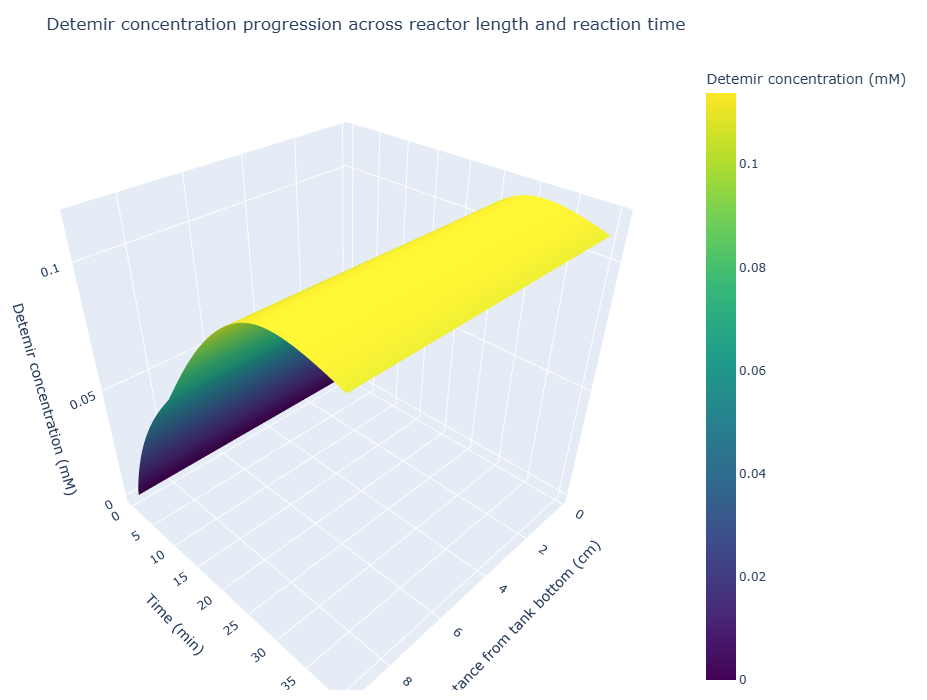

In [7]:
import plotly.graph_objects as go

# Detemir ONLY: x=distance from tank bottom, y=time, z=detemir concentration.
# Single static-in-time interactive surface (rotate/zoom in Jupyter) -- the
# full t=0..40 min progression is encoded in the y-axis, no slider needed.
X_dist_cm = z_centers * 100.0     # distance from tank bottom (cm)
Y_time_min = sol.t / 60.0         # time (min), full simulated range
Z_detemir_mM = Csol[i_det].T      # shape (n_times, N_grid) to match (y, x)

fig3d = go.Figure(data=[go.Surface(
    x=X_dist_cm,
    y=Y_time_min,
    z=Z_detemir_mM,
    colorscale='Viridis',
    colorbar=dict(title='Detemir concentration (mM)'),
)])
fig3d.update_layout(
    title='Detemir concentration progression across reactor length and reaction time',
    scene=dict(
        xaxis_title='Distance from tank bottom (cm)',
        yaxis_title='Time (min)',
        zaxis_title='Detemir concentration (mM)',
    ),
    width=900,
    height=700,
    margin=dict(l=10, r=10, t=60, b=10),
)
fig3d.show()

## Known Limitations / Next Steps

- **NHS-Myr goes locally, transiently negative (unphysical) at grid points far from the feed inlet
  during the early transient (roughly t < 10-15 min) — this is INHERITED, unchanged, from the
  underlying kinetic model, not introduced by the diffusion operator added here.** Root cause: the
  fitted NHS-Myr reaction order is very weak (`n ≈ 0.12`), so even the 1 nM smoothing floor's rate
  contribution is not small (a tiny number raised to a small fractional power is not close to zero),
  meaning the reaction keeps consuming NHS-Myr at a non-negligible rate even where none has physically
  arrived yet — exactly the caveat the source notebook's own Cell 7 comment already documents
  ("...produce unphysical negative concentrations that silently break the mass balance" for
  fractional-order kinetics without care). **We directly verified this by re-running the original,
  completely unmodified 2-compartment ODE (source Cells 9/11/15) standalone: its Zone Bulk NHS-Myr
  also goes negative, and more severely (minimum ≈ -0.036 mM) than this PDE's minimum (≈ -0.015 mM)**
  — i.e., the finer 41-point spatial grid is *better* numerically behaved than the original coarse
  2-box lumping, not worse. Per the task constraint to reuse the reaction mechanism unchanged, this
  was **not** patched by adding ad hoc state clipping (which would mask, not fix, an already-documented
  property of the fitted rate law); it is flagged here instead. It does not appear to compromise the
  macroscopic result — the domain-averaged Detemir peak still lands at t≈31.5 min vs. the lumped
  model's 30.0 min — but the sub-µM-level spatial detail near the feed-depleted region in the first
  10-15 minutes should not be over-interpreted quantitatively.
- **1D-only.** Radial and azimuthal concentration gradients are assumed negligible (justified by the
  axisymmetric, centrally-stirred, unbaffled geometry — see the ASSUMPTION block above) but not
  verified against any 2D/3D CFD or measurement.
- **`D_eff` is derived, not measured.** It comes from matching the lumped model's 2-compartment
  exchange flow `Q` to an equivalent Fickian dispersion coefficient via one characteristic length
  (`Δz_centroid`). A real eddy-dispersion coefficient is a property of the flow field, not of how many
  boxes a prior lumped model happened to use — an experimentally measured (e.g., tracer pulse/residence
  time distribution) `D_eff`, or a fine-grained CFD-derived one, would be more defensible for a real
  scale-up decision.
- **Fixed domain length.** The ~24% working-volume growth during NHS-Myr dosing (tracked exactly by
  the lumped ODE model via moles + time-varying `V1(t)`) is **not** modeled here — `L` is frozen at
  the Stage-2-start liquid height. This is the single biggest simplification relative to the source
  notebook; a moving-boundary (or periodically-regridded) PDE would be the natural next step.
- **`N_grid = 41` and the whole numerical scheme are unvalidated against experimental spatial data** —
  there is no measured intra-vessel concentration profile to check this against (only the lumped
  model's fitted, spatially-averaged pH/circulation behavior exists, from `kinetika3b.ipynb`).
  A grid-refinement study (doubling `N_grid` and confirming the solution doesn't change materially)
  would be the standard next check before trusting this for a real scale-up decision.
- **Stage 3 (glycine quench) is not included** — this notebook stops at the Detemir peak / end of
  Stage 2, matching the scope of the reused reaction network and feed schedule. Extending the same
  PDE machinery to Stage 3 would just mean adding a second inhomogeneous-Neumann feed term for
  glycine, following the same pattern as the NHS-Myr term here.
- **Dense (not sparse/banded) Jacobian.** `solve_ivp(method='Radau')` estimates a full
  `(N_grid×8)²` numerical Jacobian by finite differences. The block-tridiagonal structure of this
  problem (each grid point only couples to its two neighbors, plus all 8 species at that same point)
  could be exploited via a sparse or analytic Jacobian for a much larger grid; not needed at `N_grid=41`
  on this hardware, but would matter if `N_grid` were pushed into the hundreds.


# Appendix: from titration data to $N_q$, extending to Stage 3, and when axisymmetry breaks down

This appendix does three things, in order: (1) makes explicit the chain of physical reasoning that
turns a raw pH(t) titration trace into the flow number $N_q = 0.044$ this PDE inherits from
`kinetika3b.ipynb`, (2) gives a concrete mathematical blueprint for extending the current Stage-2-only
1D axial PDE to Stage 3 (glycine quench), and (3) states, quantitatively, what evidence would be
required before the axisymmetric assumption made in the opening markdown cell of this notebook should
be abandoned in favor of a full $(r,\theta,z)$ model. No code above this cell is modified.

---

## A1. From "time vs. pH" to $N_q$: the physical and mathematical chain

### A1.1 Why pH(t) measures mixing, not chemistry

`kinetika3b.ipynb` titrates Tris base (pH 10.5) with HCl fed continuously into Zone 1 at the liquid
surface. The proton-transfer step itself,

$$ \text{Tris} + \text{H}^+ \;\longrightarrow\; \text{TrisH}^+, $$

is a diffusion-limited acid-base reaction with a bimolecular rate constant on the order of
$10^{10}\ \text{L mol}^{-1}\text{s}^{-1}$ (Eigen-type proton transfer) — i.e. **instantaneous** on any
timescale a stirred-tank probe can resolve (seconds-to-minutes). This is the load-bearing assumption of
the whole method: because the chemical step cannot be rate-limiting, *any* time dependence observed in
the pH trace is a direct fingerprint of how fast the added protons are physically transported and
redistributed through the vessel by the impeller-driven circulation flow $Q$. The titration is,
functionally, a macro-mixing tracer experiment that happens to use a pH probe as the detector instead
of a dye/conductivity/thermal tracer.

### A1.2 The forward model that resolves $Q$ from pH(t)

`kinetika3b.ipynb` Cell 3 (`simulate_ph`) integrates a two-zone mass-action model — Zone 1 (feed zone,
volume $V_1(t)$, growing during the HCl feed) exchanging fluid at rate $Q$ with Zone B (bulk, fixed
volume $V_B$) — tracking moles of Tris and TrisH$^+$ in each zone:

$$
\frac{dn_{\text{Tris},1}}{dt} = -Q\left(\frac{n_{\text{Tris},1}}{V_1} - \frac{n_{\text{Tris},B}}{V_B}\right), \qquad
\frac{dn_{\text{TrisH},1}}{dt} = +\dot{n}_{H^+,\text{feed}}(t) - Q\left(\frac{n_{\text{TrisH},1}}{V_1} - \frac{n_{\text{TrisH},B}}{V_B}\right)
$$

(and the mirror-image pair for Zone B), with the Henderson-Hasselbalch relation
$\text{pH} = pK_a + \log_{10}([\text{Tris}]/[\text{TrisH}^+])$ converting the Zone-1 state into a
predicted pH(t) at the probe. $Q$ is the **only** free parameter; `scipy.optimize.curve_fit` finds the
$Q$ that makes the predicted Zone-1 pH(t) match the measured trace (`fit_Q`, Cell 3). Physically, $Q$ is
being resolved from the **relaxation rate of the pH transient** — a fast approach to the bulk-average pH
implies rapid inter-zone exchange (large $Q$); a slow, dragged-out approach implies the two zones are
weakly coupled (small $Q$). This is the same information content as a classical mixing-time
measurement: if one instead defined the traditional 95%-homogeneity blend time,

$$
\theta_{95} = \min\{t : |\,\text{pH}(t) - \text{pH}(\infty)\,| \le 0.05\,|\,\text{pH}(0) - \text{pH}(\infty)\,|\}
$$

$Q$ and $\theta_{95}$ are two different parameterizations of the *same* underlying two-zone relaxation
— $\theta_{95} \sim V_{\text{eff}}/Q$ up to an $O(1)$ constant set by the compartment topology. Fitting
$Q$ directly (as this repo does) is preferred here because it is the quantity that plugs directly into
$N_q$, whereas $\theta_{95}$ would need to be inverted back through the same compartment model anyway.
Note for the record: a literature search for a general turbulent $\theta_{95}$–$N_q$ correlation
*specifically for unbaffled vessels* came up empty — published blend-time correlations (e.g.
Ruszkowski's $\theta_{95} \propto 1/N$) are baffled-tank results; unbaffled vessels are widely reported
to have two distinct blend times (a fast outer-zone time and a much slower vortex-core time) with no
established general correlation. This is precisely why the empirical, single-vessel titration-fit
approach used here (rather than pulling $N_q$ from a handbook curve) is the defensible one for this
specific unbaffled IKA EASYSYN5000 geometry.

### A1.3 From $Q$ to $N_q$, and from $N_q$ to the PDE's transport coefficient

Once $Q$ is fit, `kinetika3b.ipynb` Cell 4 converts it to the dimensionless flow number

$$ N_q = \frac{Q}{N \, D_{\text{impeller}}^3} $$

($N$ in rev/s, $D_{\text{impeller}}$ in m, $Q$ in m$^3$/s) — this is the impeller-pumping analogue of a
friction factor: it packages the dimensional circulation flow into a (nominally) geometry- and
RPM-independent number so it can be rescaled to *other* RPMs on the *same* impeller via
$Q(N) = N_q \cdot N \cdot D_{\text{impeller}}^3$. That rescaling step is exactly what happens in this
PDE notebook's geometry cell: $N_q = 0.044$ (fit at 450 RPM in `kinetika3b.ipynb`) is carried over
unchanged and reapplied at the process RPM used here (160 RPM, the vortex-safe ceiling established in
`myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 4) to get this notebook's own $Q$. From there,
$D_{\text{eff}} = Q \cdot \Delta z_{\text{centroid}} / A_{\text{tank}}$ (derived in the geometry cell
above) is the axial dispersion coefficient that appears in the PDE's diffusion term
$D_{\text{eff}}\,\partial^2 C/\partial z^2$ — i.e. **the entire diffusive-transport half of this PDE
traces back, through exactly two conversions ($Q \to N_q \to Q'$), to the curvature of a measured pH(t)
curve.** The one caveat this notebook inherits unchanged from `kinetika3b.ipynb` Cell 1b/6a is that
$N_q$ is only RPM-invariant in the fully turbulent, baffled-vessel plateau; this vessel is unbaffled and
the Froude-number vortex correction there shows $N_q$ falling off with RPM rather than sitting flat — so
$N_q = 0.044$ carried into this PDE should be read as *the apparent value at 160 RPM in this specific
geometry* (kinetika3b's own Cell 6a anchors its Froude-corrected curve through this same data point),
not a universal impeller constant.

---

## A2. Blueprint: extending the PDE to Stage 3 (glycine quench)

### A2.1 What is already in place, and what genuinely needs to be added

A useful fact to state precisely, because it changes the shape of the required work: the reaction
kinetics function reused unchanged in this notebook, `reaction_derivs_mM_s`, **already** contains the
full glycine-quench chemistry —

```
r_quench = calc_rate_mM_s(k_quench, NHS, GLY)     # NHS-Myr + glycine -> gly_myr
d['nhs_myr'] -= r_quench;  d['glycine'] = -r_quench;  d['gly_myr'] = +r_quench
```

— and `glycine`/`gly_myr` are already members of `REACTIVE_SPECIES` and therefore already carried as
two of the $N_{\text{grid}} \times 8$ state variables integrated by `solve_ivp` in this very notebook
(they are simply initialized to zero everywhere and never fed, so $r_{\text{quench}} \equiv 0$
throughout the current run — consistent with the "Stage 3 not spatially resolved" line in Known
Limitations below). **No change to the reaction-rate machinery is required.** Extending to Stage 3 is
therefore purely a *transport/boundary-condition/event-detection* problem, not a kinetics problem —
which is exactly the kind of extension this PDE's method-of-lines architecture is designed to absorb
without touching `reaction_derivs_mM_s`.

### A2.2 Required addition 1 — peak-detection as a spatial aggregation problem

`myr_mechanistic_model_5L_optimized_FIXED.ipynb`'s lumped ODE model triggers the glycine feed at a
single well-defined instant: the Detemir concentration peak (`run_stage_2_dosed` → peak search →
`run_stage_3_quench`). In the PDE, Detemir concentration is a field $C_{\text{det}}(z,t)$, not a scalar,
so "the peak" must first be defined as a scalar functional of that field before an event can be
triggered on it. The physically correct choice is the volume-weighted spatial average (this is also
what a single outlet/sampling port would measure):

$$
\bar{C}_{\text{det}}(t) = \frac{1}{L}\int_0^L C_{\text{det}}(z,t)\, dz \;\approx\; \frac{1}{N_{\text{grid}}}\sum_{j=1}^{N_{\text{grid}}} C_{\text{det}}(z_j, t)
$$

(equal-weighted because the current grid is uniform in $z$ with equal cell volumes). The quench trigger
condition becomes a `solve_ivp` terminal event on $d\bar{C}_{\text{det}}/dt = 0$ (sign change from + to
&minus;), directly analogous to `make_nhs_exhausted_event` already used for the Stage-2→3 transition in
the ODE notebook, just evaluated on the spatial mean rather than a single-compartment value. Because
axial gradients in Detemir are shown in this notebook's own axial-profile plot to be small relative to
NHS-Myr's (see the conceptual explanation given earlier in this session: Detemir's source term depends
on *substrate*, not on the steeply-graded NHS-Myr field directly, so it stays comparatively uniform),
$\bar{C}_{\text{det}}(t)$ should track the lumped model's peak-time (t≈30 min SOP value) closely — this
is itself a testable consistency check once implemented, in the same spirit as the domain-averaged
Detemir peak comparison (31.5 min PDE vs. 30.0 min lumped) already reported in this notebook.

### A2.3 Required addition 2 — a second, time-shifted inhomogeneous Neumann BC

Once the trigger fires at $t = t_{\text{peak}}$, glycine must be dosed through the **same physical
inlet** as NHS-Myr (`myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 9: same peristaltic pump,
same top-of-Zone-1 entry point), which in this PDE's coordinate system is the same $z=L$ boundary
already used for the NHS-Myr feed. The boundary condition to add is structurally identical to the
existing NHS-Myr feed BC, only species-swapped and time-shifted:

$$
-D_{\text{eff}}\left.\frac{\partial C_{\text{gly}}}{\partial z}\right|_{z=L} = \frac{\dot{n}_{\text{gly,feed}}}{A_{\text{tank}}}
\quad \text{for} \quad t_{\text{peak}} \le t < t_{\text{peak}} + T_{\text{gly,feed}}
$$

with $\dot{n}_{\text{gly,feed}} = \text{dose}_{\text{gly}} / T_{\text{gly,feed}}$, where
$\text{dose}_{\text{gly}} = 1.1\times\left(\text{total NHS-Myr remaining at } t_{\text{peak}}\right)$ and
$T_{\text{gly,feed}}$ is set by the shared pump's flow rate (10–200 mL/min) — using exactly the same
excess-factor and pump-sizing logic already implemented in `run_stage_3_quench`. Implementation-wise
this is a one-line addition to the top-grid-cell source term in `pde_rhs`, gated on
`t_peak <= t < t_peak + T_gly_feed_s` instead of `t < T_feed_s`, mirroring the existing NHS-Myr feed-gate
pattern exactly. All species keep homogeneous Neumann (no-flux) at $z=0$ throughout, unchanged.

### A2.4 Required addition 3 — the second moving-boundary problem

The domain length $L$ in this notebook is already a known simplification (frozen at the Stage-2-start
value; see Known Limitations). Adding Stage 3 makes this approximation compound: the vessel volume grows
*twice* — once during NHS-Myr dosing, again during glycine dosing — and by A2.2 the second growth event
starts at a *data-dependent* time ($t_{\text{peak}}$), not a fixed one. Two implementation paths, in
order of increasing rigor:
1. **Cheapest, consistent with the existing approximation:** keep $L$ frozen at its Stage-2 value for
   the whole simulation (i.e., extend the existing simplification rather than removing it) — defensible
   because the glycine dose is sized to a small residual NHS-Myr excess and is reported as small in
   `myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 9, so the second volume increment is a minor
   perturbation on top of an already-approximate domain length.
2. **Rigorous:** introduce a time-varying domain length $L(t)$ (from Stage 2 onward) and solve on a
   Landau-transformed fixed computational coordinate $\zeta = z / L(t)$, which turns the moving physical
   boundary into a fixed $\zeta \in [0,1]$ domain at the cost of an added advective term
   $-\dfrac{\zeta}{L}\dfrac{dL}{dt}\dfrac{\partial C}{\partial \zeta}$ in the transformed PDE. This is
   the standard fixed-grid technique for a single stagnant-boundary Stefan-like moving domain (`
   phys430python.pdf` does not cover this case; it is a well-known extension in the finite-difference
   PDE literature) and is the right tool if the ~24%(Stage 2) + further Stage-3 volume growth is judged
   too large to keep neglecting.

---

## A3. When to abandon axisymmetry: criteria for a $(r,\theta,z)$ model

### A3.1 What the current 1D assumption actually claims, precisely stated

The opening markdown cell's ASSUMPTION is that a centered, vertical impeller shaft in a round, unbaffled,
non-sparged tank produces **axisymmetric mean flow**: $\partial C/\partial\theta = 0$ at every $(r,z)$,
so only the axial coordinate carries a resolvable concentration gradient, and the governing equation
collapses from the full cylindrical transport equation

$$
\frac{\partial C}{\partial t} = D_{\text{eff}}\left[\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\frac{\partial C}{\partial r}\right) + \frac{1}{r^2}\frac{\partial^2 C}{\partial \theta^2} + \frac{\partial^2 C}{\partial z^2}\right] + R(C)
$$

down to the $z$-only form actually solved here. This is a claim about the **flow field**, not a
convenience — it is only true to the extent the real vessel is free of persistent angular structure
(azimuthal recirculation cells, wall-bound stagnant pockets, or precessing vortex asymmetry).

### A3.2 Quantitative promotion criteria

The assumption should be treated as falsified — and the model upgraded — once **any** of the following
is observed, each tied to a specific measurement technique:

1. **Multi-point azimuthal pH/conductivity sensor array.** Instrument the vessel with $\ge 3$ probes at
   the *same* $(r, z)$ but different $\theta$ (e.g., 0°, 120°, 240°), repeat the `kinetika3b.ipynb`
   titration protocol, and compare the fitted local relaxation curves. Define the azimuthal
   inhomogeneity metric
   $$
   \text{CV}_\theta(t) = \frac{\sigma_\theta[\,\text{pH}(r,\theta,z,t)\,]}{\left|\overline{\text{pH}}_\theta(t) - \text{pH}(\infty)\right|}
   $$
   at fixed $(r,z)$. A statistically significant $\text{CV}_\theta$ (assessed by repeat-run ANOVA against
   probe noise, not eyeballed) sustained over multiple mixing-time windows indicates a real angular
   structure, not sensor noise — this is the direct, quantitative generalization of the existing
   single-probe method in `kinetika3b.ipynb`, which by construction cannot see this (it has exactly one
   $\theta$ position and says so in its own Cell 1).
2. **Planar Laser-Induced Fluorescence (PLIF).** Seed the vessel with a fluorescent tracer (fed at the
   same $z=L$ inlet used for NHS-Myr/glycine) and image concentration fields in horizontal ($r,\theta$)
   slices at fixed $z$ using a laser sheet. A field that stays annular/uniform in $\theta$ at every
   imaged $t$ supports the axisymmetric assumption; a field showing a persistent, non-rotating
   high/low-concentration lobe (a "hot spot" or "cold pocket" that does not simply track the impeller's
   instantaneous angular position) is direct visual evidence of broken axisymmetry. PLIF is the
   established technique for exactly this diagnostic (see Cabaret & Fournier-type PLIF mixing-time
   studies for baffled and unbaffled vessels; unbaffled eccentric-impeller PLIF/PIV studies specifically
   report this kind of persistent pocket formation).
3. **Tomographic/stereo PIV.** Reconstruct the 3D mean velocity field $\mathbf{u}(r,\theta,z)$. Compute
   the azimuthal component of the *mean* (not instantaneous, turbulent) velocity, $\overline{u_\theta}$,
   at fixed $(r,z)$ across $\theta$: under true axisymmetry this should be independent of $\theta$ (by
   definition of the mean flow, not the fluctuating field). A mean-flow asymmetry exceeding measurement
   uncertainty — most commonly caused in unbaffled vessels by the free-surface vortex itself becoming
   eccentric/precessing rather than staying centered on the shaft axis at higher Froude number (relevant
   here since `kinetika3b.ipynb` Cell 1b already flags this vessel as unbaffled and Froude-sensitive) —
   is grounds for promotion.
4. **Mechanical/geometric red flags that predict the above without new instrumentation.** Any measured
   impeller-shaft eccentricity or angular tilt relative to the tank centerline, a non-circular vessel
   cross-section, or an asymmetric baffle/probe intrusion (the existing temperature probe at ~30° is
   already noted in `kinetika3b.ipynb` Cell 1 as a "pseudo-baffle" — a single such intrusion breaks
   perfect axisymmetry in principle; the open question this notebook leaves unresolved is only whether
   its effect is large enough to matter against the other approximations already stacked into
   $D_{\text{eff}}$).

### A3.3 What the upgrade costs, and why it hasn't been done pre-emptively

If criterion (1), (2), or (3) is met, the correct next model is the full cylindrical PDE in §A3.1,
discretized in $(r,\theta,z)$ — well beyond a `numpy`/`scipy.integrate.solve_ivp` finite-difference
method-of-lines scheme of this notebook's size ($N_{\text{grid}} \times 8$ ODEs here; a comparable
$(r,\theta,z)$ grid would multiply the state count by $O(10^2)$–$O(10^3)$) and would motivate the
finite-element toolchain (FEniCS/`dolfin`) already flagged as unavailable and unnecessary in this
notebook's opening ASSUMPTION block. Absent any of the four triggers above, adding that complexity would
model an effect the vessel's own geometry and the existing single-probe titration data give no evidence
for — which is precisely the justification already given for staying 1D. This section exists so that
if/when such evidence *is* collected, the upgrade path is already specified rather than requiring a
fresh derivation.

---

*This appendix adds no new executable code and modifies no cell above it. It documents the
parameter-provenance chain for $N_q$/$D_{\text{eff}}$, a concrete (not-yet-implemented) extension path
for Stage 3, and falsifiable, measurement-backed criteria for when the 1D axial assumption in this
notebook should be revisited.*
